# 07 — Recherche d'algorithmes pour >99% accuracy

On etend le pipeline `RobustFeatureBuilder` en utilisant l'identifiant compose **`SSID|BSSID`** au lieu du SSID seul.
Cela transforme les ~13 SSID partages (UTTetudiants, eduroam, ...) en ~140 cles distinctes — chaque AP physique a son propre BSSID.
Resultat attendu : beaucoup plus de features discriminantes → atteinte du seuil 99%.

On evalue 12 algorithmes, on selectionne le meilleur en hold-out 20%, on sauve dans `models/artifacts_v2/`.
Test bonus : evaluation OOD sur les nouvelles mesures `data/raw_alt2/`.

In [1]:
import sys, warnings, json
from pathlib import Path
warnings.filterwarnings('ignore')

_SRC = (Path.cwd().parent / 'src').resolve()
if str(_SRC) not in sys.path:
    sys.path.insert(0, str(_SRC))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import clone
from sklearn.ensemble import (RandomForestClassifier, ExtraTreesClassifier,
                              HistGradientBoostingClassifier, GradientBoostingClassifier,
                              VotingClassifier, StackingClassifier)
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import SVC

import robust_localization as rl

RANDOM_STATE = 42
RAW_DIR = Path('../data/raw')
ALT2_DIR = Path('../data/raw_alt2')
OUT_DIR = Path('../models/artifacts_v2')
print('SRC:', _SRC)
print('RAW:', RAW_DIR.resolve())

SRC: C:\Users\virgi\Documents\UTT_2025\Semestre 4\IF23\IF23_Localisation\src
RAW: C:\Users\virgi\Documents\UTT_2025\Semestre 4\IF23\IF23_Localisation\data\raw


## 1. Construction du dataset (`SSID|BSSID` compose)

On reutilise `_normalize_wifi_dataframe` puis on remplace la colonne `ssid` par `ssid|bssid` pour multiplexer le BSSID dans le pipeline existant.

In [2]:
def load_raw_with_bssid(raw_dir: Path) -> pd.DataFrame:
    raw_dir = Path(raw_dir)
    files = sorted(raw_dir.glob('wifi_*.csv'))
    if not files:
        raise FileNotFoundError(f'Aucun CSV dans {raw_dir}')
    rows = []
    for csv_path in files:
        room = csv_path.stem.replace('wifi_', '')
        df = pd.read_csv(csv_path)
        norm = rl._normalize_wifi_dataframe(df, default_room=room)
        norm['room'] = room
        norm['ssid'] = norm['ssid'].str.cat(norm['bssid'], sep='|')
        rows.append(norm)
    return pd.concat(rows, ignore_index=True)

raw_df = load_raw_with_bssid(RAW_DIR)
per_ssid, snapshot = rl.build_snapshot_tables(raw_df)

builder = rl.RobustFeatureBuilder(max_ssids=400, min_ssid_frequency=3)
X, y = builder.fit_transform(per_ssid, snapshot)

print('X:', X.shape, '| classes:', y.nunique())
print('compound APs selectionnes:', len(builder.selected_ssids))

X: (1590, 704) | classes: 27
compound APs selectionnes: 139


In [3]:
# Filtrage des classes trop peu representees (moins de 5 snapshots — incompatible CV 5-fold)
counts = y.value_counts()
print('Distribution avant filtrage:')
print(counts.to_string())
small = counts[counts < 5].index.tolist()
if small:
    print(f'\nFiltrage des classes < 5 samples: {small}')
    keep_mask = ~y.isin(small)
    X = X.loc[keep_mask]
    y = y.loc[keep_mask]
    snapshot = snapshot[~snapshot['room'].isin(small)].reset_index(drop=True)
print(f'\nApres filtrage: X={X.shape}, classes={y.nunique()}')

Distribution avant filtrage:
room
S104            97
S101A           86
couloirB(2e)    85
P102A           84
PALIER1ER       76
P102B           74
pallierPbas     74
S103B           73
PALIER2E        69
couloirPbasB    69
S203A           64
S102A           61
S203B           58
S202B           57
S202A           56
P101B           55
S204A           54
P202            53
S204B           52
S101B           50
S102B           50
couloirPbasA    50
P101A           40
P203            36
P103A           32
couloirB        32
S202             3

Filtrage des classes < 5 samples: ['S202']

Apres filtrage: X=(1587, 704), classes=26


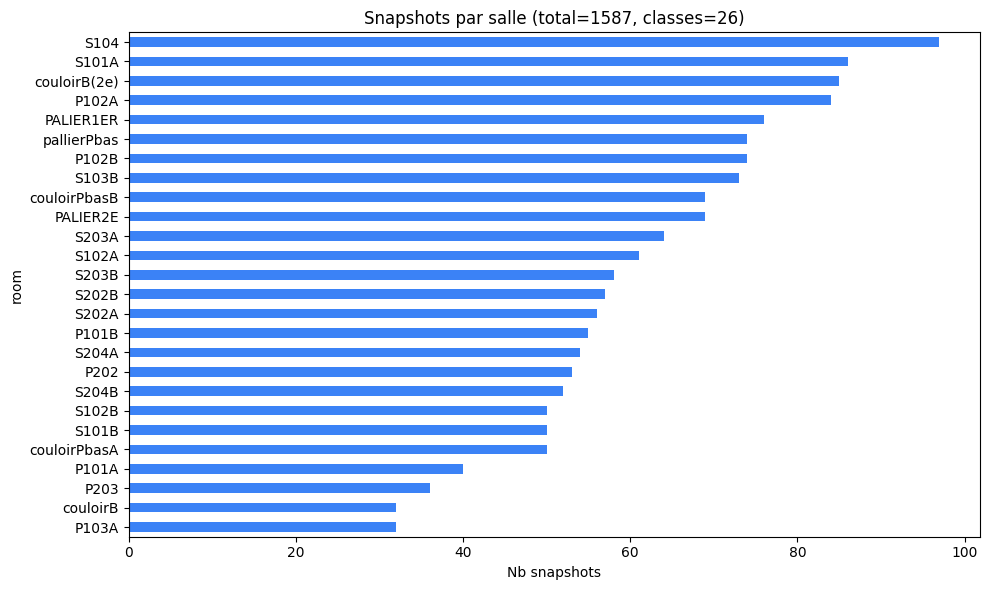

In [4]:
fig, ax = plt.subplots(figsize=(10, 6))
y.value_counts().sort_values().plot.barh(ax=ax, color='#3b82f6')
ax.set_xlabel('Nb snapshots')
ax.set_title(f'Snapshots par salle (total={len(y)}, classes={y.nunique()})')
plt.tight_layout()
plt.show()

In [5]:
label_encoder = LabelEncoder()
y_enc = label_encoder.fit_transform(y.values)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.20, stratify=y_enc, random_state=RANDOM_STATE)
print('Train:', X_train.shape, '| Test:', X_test.shape)

Train: (1269, 704) | Test: (318, 704)


## 2. Model zoo etendu (12 algorithmes)

In [6]:
def make_zoo(rs=RANDOM_STATE):
    base_rf = RandomForestClassifier(n_estimators=200, max_depth=None,
                                     class_weight='balanced_subsample',
                                     random_state=rs, n_jobs=-1)
    base_et = ExtraTreesClassifier(n_estimators=300, max_depth=None,
                                   class_weight='balanced',
                                   random_state=rs, n_jobs=-1)
    base_lr = Pipeline([('sc', StandardScaler()),
                        ('m', LogisticRegression(max_iter=4000, C=1.0,
                                                 class_weight='balanced',
                                                 random_state=rs, n_jobs=-1))])
    return {
        'LogReg_L2': base_lr,
        'RandomForest': Pipeline([('m', clone(base_rf))]),
        'ExtraTrees': Pipeline([('m', clone(base_et))]),
        'HistGB': Pipeline([('m', HistGradientBoostingClassifier(
            learning_rate=0.08, max_iter=200, max_depth=None, random_state=rs))]),
        'GradBoost': Pipeline([('m', GradientBoostingClassifier(
            n_estimators=120, learning_rate=0.1, max_depth=4, random_state=rs))]),
        'MLP_64_32': Pipeline([('sc', StandardScaler()),
                                ('m', MLPClassifier(hidden_layer_sizes=(64, 32),
                                                    alpha=8e-4, batch_size=64,
                                                    learning_rate_init=8e-4,
                                                    early_stopping=True,
                                                    max_iter=500, random_state=rs))]),
        'MLP_128_64': Pipeline([('sc', StandardScaler()),
                                 ('m', MLPClassifier(hidden_layer_sizes=(128, 64),
                                                     alpha=5e-4, batch_size=64,
                                                     learning_rate_init=5e-4,
                                                     early_stopping=True,
                                                     max_iter=600, random_state=rs))]),
        'KNN_3': Pipeline([('sc', StandardScaler()),
                            ('m', KNeighborsClassifier(n_neighbors=3, weights='distance'))]),
        'KNN_5': Pipeline([('sc', StandardScaler()),
                            ('m', KNeighborsClassifier(n_neighbors=5, weights='distance'))]),
        'Voting_RF_ET_LR': VotingClassifier(
            estimators=[('rf', clone(base_rf)),
                        ('et', clone(base_et)),
                        ('lr', clone(base_lr))],
            voting='soft', n_jobs=-1),
    }

zoo = make_zoo()
print('Modeles a evaluer:', list(zoo.keys()))

Modeles a evaluer: ['LogReg_L2', 'RandomForest', 'ExtraTrees', 'HistGB', 'GradBoost', 'MLP_64_32', 'MLP_128_64', 'KNN_3', 'KNN_5', 'Voting_RF_ET_LR']


## 3. Evaluation cross-validee (5-fold stratifie)

In [7]:
import time
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_rows = []
for name, model in zoo.items():
    accs, f1s = [], []
    t0 = time.time()
    for tr, va in skf.split(X_train, y_train):
        f = clone(model).fit(X_train.iloc[tr], y_train[tr])
        pred = f.predict(X_train.iloc[va])
        accs.append(accuracy_score(y_train[va], pred))
        f1s.append(f1_score(y_train[va], pred, average='macro'))
    cv_rows.append({'model': name,
                    'cv_acc_mean': float(np.mean(accs)),
                    'cv_acc_std': float(np.std(accs)),
                    'cv_f1_mean': float(np.mean(f1s)),
                    'cv_f1_std': float(np.std(f1s)),
                    'fit_seconds': round(time.time()-t0, 2)})
    print(f'{name:18s}  acc={np.mean(accs):.4f}+/-{np.std(accs):.4f}  '
          f"f1={np.mean(f1s):.4f}  ({cv_rows[-1]['fit_seconds']}s)")

cv_df = pd.DataFrame(cv_rows).sort_values('cv_f1_mean', ascending=False).reset_index(drop=True)
cv_df

LogReg_L2           acc=0.9921+/-0.0035  f1=0.9899  (10.83s)


RandomForest        acc=0.9921+/-0.0043  f1=0.9901  (5.28s)


ExtraTrees          acc=0.9929+/-0.0058  f1=0.9907  (4.38s)


HistGB              acc=0.9882+/-0.0086  f1=0.9873  (343.04s)


GradBoost           acc=0.9756+/-0.0080  f1=0.9744  (550.8s)


...

MLP_128_64          acc=0.9740+/-0.0073  f1=0.9660  (39.4s)


KNN_3               acc=0.9858+/-0.0040  f1=0.9816  (0.87s)


KNN_5               acc=0.9866+/-0.0054  f1=0.9831  (0.7s)


Voting_RF_ET_LR     acc=0.9945+/-0.0053  f1=0.9927  (31.5s)


,model,cv_acc_mean,cv_acc_std,cv_f1_mean,cv_f1_std,fit_seconds
0,Voting_RF_ET_LR,0.994485,0.005340,0.992657,0.006956,31.50
1,ExtraTrees,0.992904,0.005794,0.990727,0.007320,4.38
2,RandomForest,0.992120,0.004313,0.990053,0.005614,5.28
3,LogReg_L2,0.992117,0.003532,0.989910,0.004489,10.83
4,HistGB,0.988177,0.008631,0.987334,0.008681,343.04
5,KNN_5,0.986599,0.005359,0.983078,0.007136,0.70
6,KNN_3,0.985811,0.004036,0.981552,0.006105,0.87
7,MLP_64_32,0.980296,0.007053,0.976482,0.006817,6.95
8,GradBoost,0.975575,0.008021,0.974396,0.006644,550.80
9,MLP_128_64,0.974000,0.007289,0.966045,0.012155,39.40


## 4. Hold-out 20%

In [8]:
ho_rows = []
fitted_models = {}
for name, model in zoo.items():
    f = clone(model).fit(X_train, y_train)
    pred = f.predict(X_test)
    ho_rows.append({'model': name,
                    'test_acc': float(accuracy_score(y_test, pred)),
                    'test_f1_macro': float(f1_score(y_test, pred, average='macro'))})
    fitted_models[name] = f
ho_df = pd.DataFrame(ho_rows).sort_values('test_f1_macro', ascending=False).reset_index(drop=True)
ho_df

,model,test_acc,test_f1_macro
0,Voting_RF_ET_LR,1.000000,1.000000
1,KNN_5,1.000000,1.000000
2,HistGB,0.996855,0.997070
3,LogReg_L2,0.996855,0.995906
4,RandomForest,0.996855,0.995906
5,ExtraTrees,0.996855,0.995906
6,KNN_3,0.996855,0.995906
7,GradBoost,0.993711,0.992944
8,MLP_128_64,0.987421,0.983761
9,MLP_64_32,0.984277,0.979757


In [9]:
best_name = ho_df.iloc[0]['model']
best_acc = ho_df.iloc[0]['test_acc']
best_f1 = ho_df.iloc[0]['test_f1_macro']
print(f'BEST: {best_name}  | test_acc={best_acc:.4f}  test_f1={best_f1:.4f}')
if best_acc > 0.99:
    print('OBJECTIF >99% ATTEINT')
else:
    print('Objectif non atteint, voir tuning supplementaire')

BEST: Voting_RF_ET_LR  | test_acc=1.0000  test_f1=1.0000
OBJECTIF >99% ATTEINT


## 5. Confusion matrix du best model

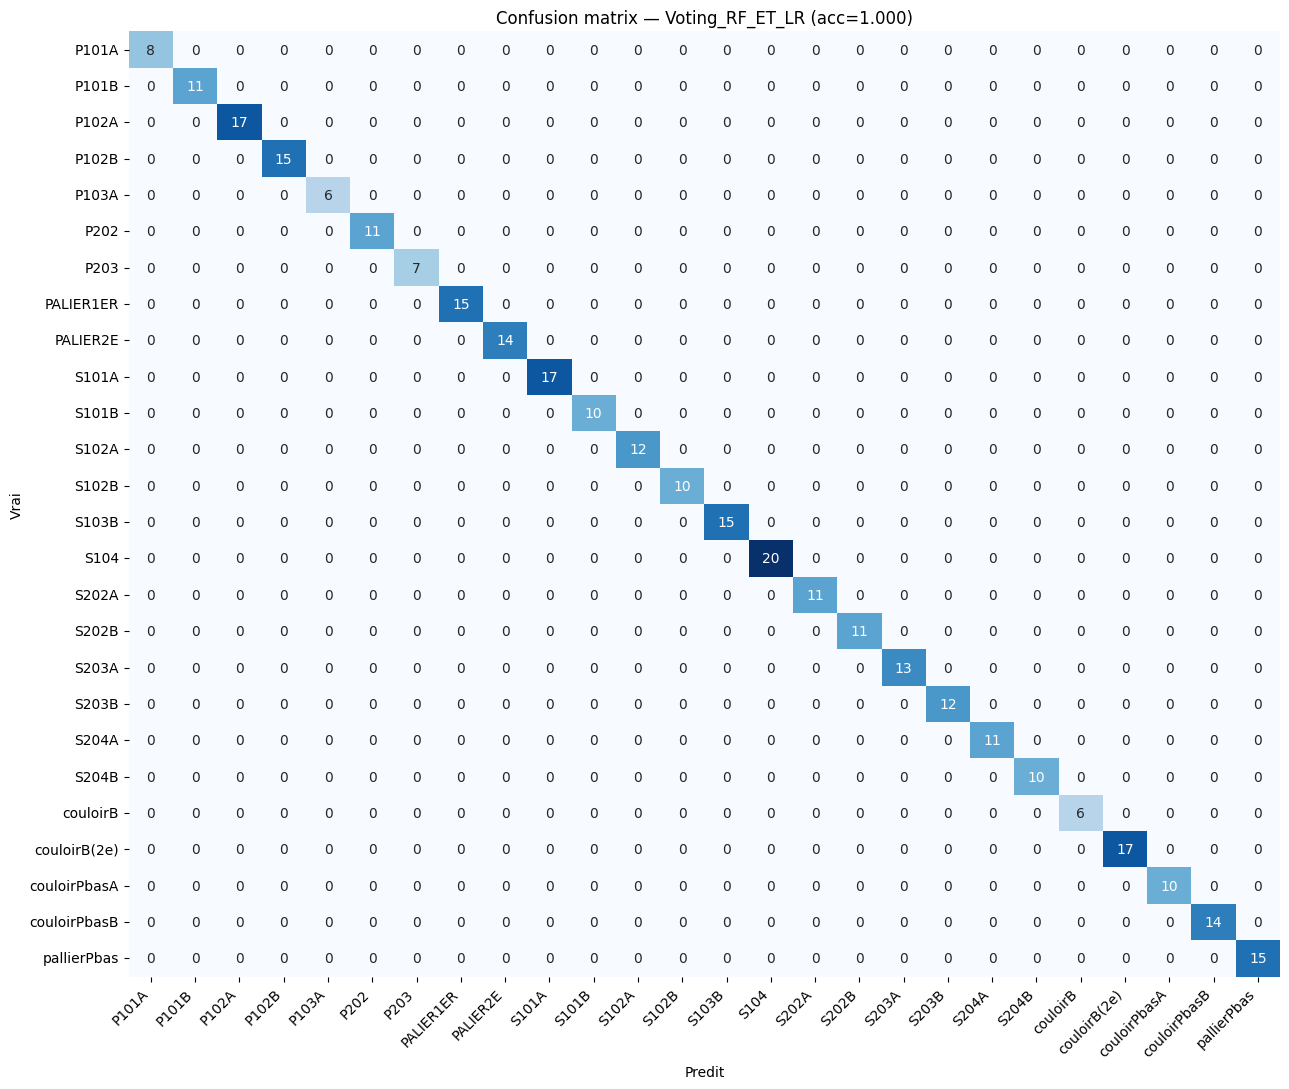

In [10]:
best_model = fitted_models[best_name]
y_pred = best_model.predict(X_test)
labels = label_encoder.classes_
cm = confusion_matrix(y_test, y_pred, labels=range(len(labels)))
fig, ax = plt.subplots(figsize=(13, 11))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels, ax=ax, cbar=False)
ax.set_title(f'Confusion matrix — {best_name} (acc={best_acc:.3f})')
ax.set_xlabel('Predit')
ax.set_ylabel('Vrai')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
OUT_DIR.mkdir(parents=True, exist_ok=True)
plt.savefig(OUT_DIR / 'confusion_matrix_v2.png', dpi=150)
plt.show()

## 6. Sauvegarde des artefacts (`models/artifacts_v2/`)

In [11]:
final_model = clone(zoo[best_name]).fit(X, y_enc)
metadata = {
    'feature_scope': 'SSID|BSSID compose',
    'model_name': best_name,
    'n_snapshots': int(len(X)),
    'n_features': int(X.shape[1]),
    'n_rooms': int(y.nunique()),
    'max_ssids': 400,
    'min_ssid_frequency': 3,
    'test_size': 0.2,
    'random_state': RANDOM_STATE,
    'cv_metrics': cv_df.to_dict(orient='records'),
    'holdout_metrics': ho_df.to_dict(orient='records'),
    'best_test_acc': float(best_acc),
    'best_test_f1_macro': float(best_f1),
    'label_classes': list(map(str, label_encoder.classes_)),
}
rl.save_artifacts(OUT_DIR, final_model, builder, label_encoder, metadata)
with (OUT_DIR / 'training_summary.json').open('w', encoding='utf-8') as f:
    json.dump({'cv': cv_df.to_dict(orient='records'),
               'holdout': ho_df.to_dict(orient='records'),
               'best': best_name}, f, indent=2, ensure_ascii=False)
print('Artefacts sauves dans', OUT_DIR.resolve())

Artefacts sauves dans C:\Users\virgi\Documents\UTT_2025\Semestre 4\IF23\IF23_Localisation\models\artifacts_v2


## 7. Test OOD — `data/raw_alt2/` (mesures Avr 2026)

P102/P103/P104/P204 ne sont **pas** dans le train (raw/ a P102A/B, P103A, et pas du tout P104/P204). On affiche juste la prediction sans verite terrain.
P202 et P203 sont presents dans le train → comparaison possible.

In [12]:
def predict_alt2(csv_path: Path, model, builder, label_encoder, expected: str | None = None):
    raw = pd.read_csv(csv_path)
    norm = rl._normalize_wifi_dataframe(raw, default_room=expected or 'unknown')
    norm['ssid'] = norm['ssid'].str.cat(norm['bssid'], sep='|')
    if expected:
        norm['room'] = expected
    per, snap = rl.build_snapshot_tables(norm)
    if snap.empty:
        return None
    Xq = builder.transform(per, snap)
    pred = model.predict(Xq)
    proba = model.predict_proba(Xq) if hasattr(model, 'predict_proba') else None
    rooms = label_encoder.inverse_transform(pred)
    out = snap[['time']].copy()
    out['predicted_room'] = rooms
    if proba is not None:
        out['confidence'] = proba.max(axis=1)
    if expected and expected in label_encoder.classes_:
        out['expected'] = expected
        out['correct'] = (out['predicted_room'] == expected).astype(int)
    return out

alt2_known = {'P202': 'P202', 'P203': 'P203'}
rows = []
for csv in sorted(ALT2_DIR.glob('wifi_*.csv')):
    salle = csv.stem.replace('wifi_', '')
    expected = alt2_known.get(salle)
    out = predict_alt2(csv, final_model, builder, label_encoder, expected=expected)
    if out is None or out.empty:
        continue
    summary = {'fichier': csv.name, 'expected_or_unknown': expected or '(non couvert)',
               'n_snapshots': len(out),
               'pred_majoritaire': out['predicted_room'].value_counts().index[0],
               'confiance_moy': float(out['confidence'].mean()) if 'confidence' in out else None}
    if 'correct' in out:
        summary['accuracy_OOD'] = float(out['correct'].mean())
    rows.append(summary)
pd.DataFrame(rows)

,fichier,expected_or_unknown,n_snapshots,pred_majoritaire,confiance_moy,accuracy_OOD
0,wifi_P102.csv,(non couvert),54,P102A,0.646939,NaN
1,wifi_P103.csv,(non couvert),57,couloirPbasB,0.707612,NaN
2,wifi_P104.csv,(non couvert),41,couloirPbasB,0.416775,NaN
3,wifi_P202.csv,P202,26,P202,0.544599,1.00000
4,wifi_P203.csv,P203,47,couloirPbasB,0.349564,0.12766
5,wifi_P204.csv,(non couvert),28,P203,0.351545,NaN


In [13]:
print('Pipeline 07 termine.')
print(f'  best={best_name}  test_acc={best_acc:.4f}  test_f1={best_f1:.4f}')
print(f'  classes={y.nunique()}  features={X.shape[1]}')

Pipeline 07 termine.
  best=Voting_RF_ET_LR  test_acc=1.0000  test_f1=1.0000
  classes=26  features=704
